# MEG Decoding Toolkit — Rule-Type Decoding Demo

Demonstrates the three feature×decoder combinations on sub-001:

| # | Feature | Decoder | Analysis |
|---|---------|---------|----------|
| 5.1 | Raw amplitude | Ridge logistic | rule3 epochs, rule_type label |
| 5.2 | Time-frequency (stacked) | Ridge logistic | rule3 epochs |
| 5.3 | Riemannian covariance | Linear SVM | transition epochs |

All decoding is **5-fold stratified CV** with no leakage.

In [6]:
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # make toolkit importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
mne.set_log_level('WARNING')

from toolkit import (
    RawAmplitudeFeature, TimeFrequencyFeature, RiemannianCovarianceFeature,
    RidgeLogisticDecoder, SVMDecoder,
    CVSplitter, cross_validate,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load data

In [7]:
EPOCHS_PATH = '/home/timmy/storage/NEU502B/brain-binding/tim/ported_results/sub-001_ses-01_task-binding_epo.fif'
BEHAV_PATH  = '/home/timmy/storage/NEU502B/brain-binding/data/2026-04-10/sub-001_events.csv'

epochs = mne.read_epochs(EPOCHS_PATH, preload=True)
df = pd.read_csv(BEHAV_PATH).sort_values('trial').reset_index(drop=True)

sfreq = epochs.info['sfreq']
times = epochs.times
n_trials = len(df)
print(f'Epochs shape: {epochs.get_data(picks="meg").shape}')
print(f'Trials: {n_trials}, sfreq: {sfreq} Hz, times: {times[0]:.3f}–{times[-1]:.3f} s')

KeyboardInterrupt: 

## 2. Helper: extract one within-trial stage

In [ ]:
STAGE_OFFSETS = {
    'fixation': 0, 'rule1': 1, 'rule2': 2, 'rule3': 3,
    'transition': 4, 'test1': 5, 'test2': 6, 'test3': 7, 'response': 8,
}

def get_stage(stage_name: str):
    """Return (X, times) for the given within-trial stage across all trials."""
    offset = STAGE_OFFSETS[stage_name]
    idx = [9 * t + offset for t in range(n_trials)]
    X = epochs[idx].get_data(picks='meg').astype(np.float32)
    return X

# Binary label: ABA=0, ABB=1
y_rule = (df['rule_type'] == 'ABB').values.astype(int)
print(f'rule_type counts: {dict(zip(*np.unique(y_rule, return_counts=True)))}')

rule_type counts: {0: 60, 1: 60}


## 3. Example 5.1 — Raw-amplitude MVPA on rule3

In [ ]:
X_rule3.shape

(120, 192, 201)

rule1 result: CVResult(decoder='RidgeLogisticDecoder', feature='RawAmplitudeFeature', folds=5, n_models=181, grand_mean=0.5084)


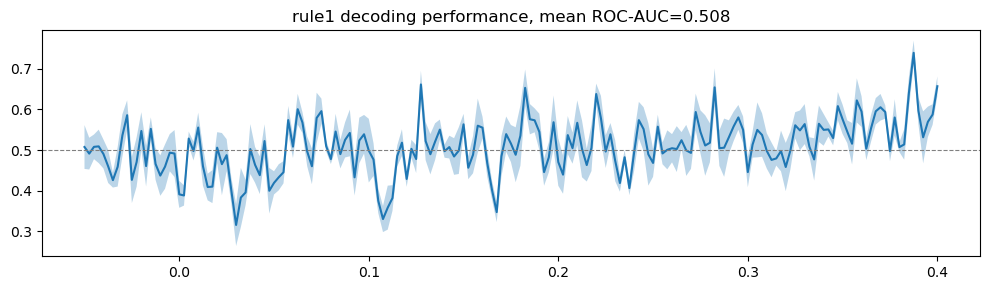

rule2 result: CVResult(decoder='RidgeLogisticDecoder', feature='RawAmplitudeFeature', folds=5, n_models=181, grand_mean=0.4902)


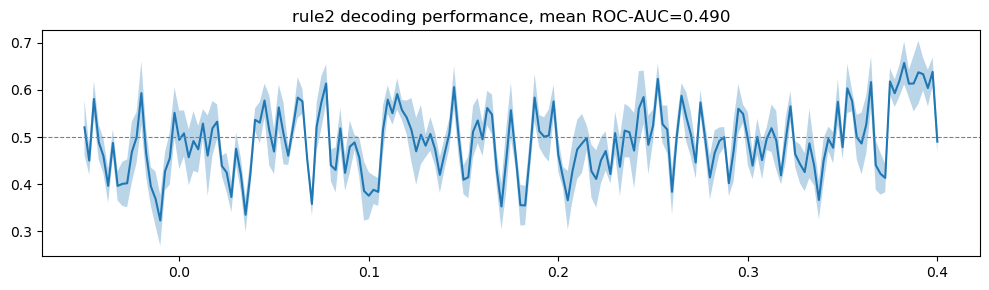

rule3 result: CVResult(decoder='RidgeLogisticDecoder', feature='RawAmplitudeFeature', folds=5, n_models=181, grand_mean=0.5455)


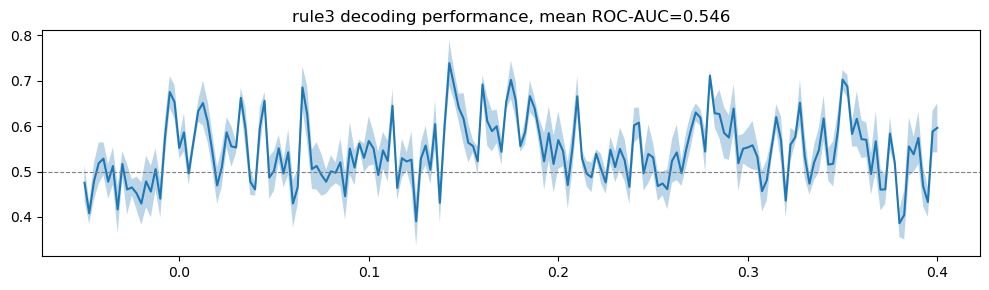

transition result: CVResult(decoder='RidgeLogisticDecoder', feature='RawAmplitudeFeature', folds=5, n_models=181, grand_mean=0.5568)


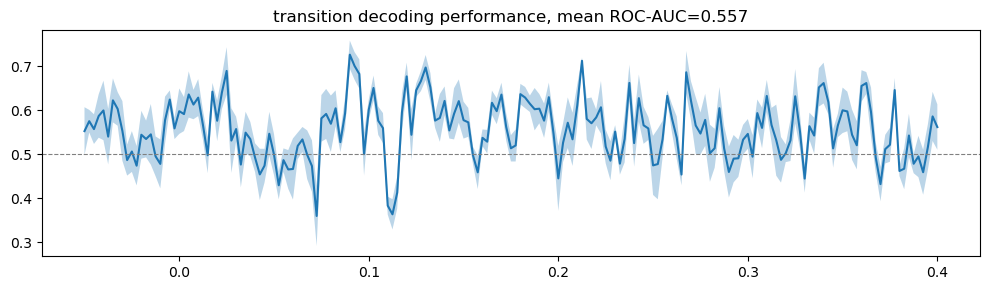

test1 result: CVResult(decoder='RidgeLogisticDecoder', feature='RawAmplitudeFeature', folds=5, n_models=181, grand_mean=0.5141)


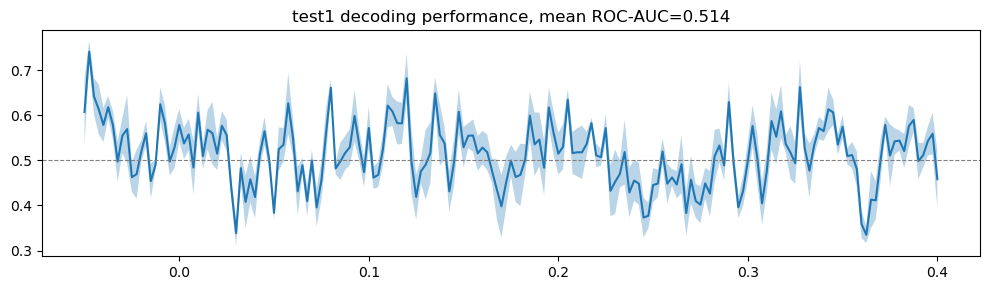

test2 result: CVResult(decoder='RidgeLogisticDecoder', feature='RawAmplitudeFeature', folds=5, n_models=181, grand_mean=0.4840)


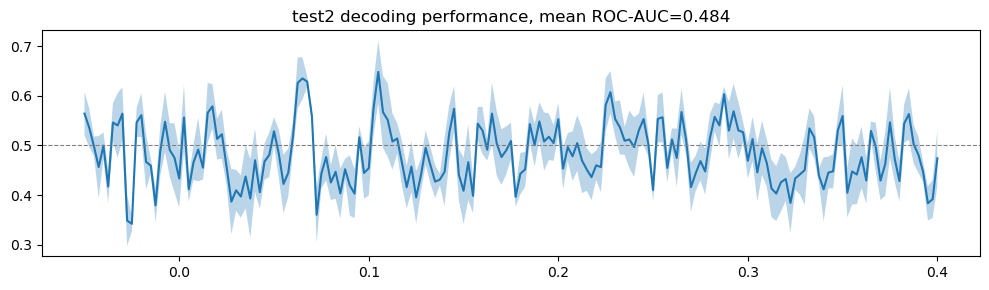

In [ ]:
X_rule1 = get_stage('rule1')
X_rule2 = get_stage('rule2')
X_rule3 = get_stage('rule3')
X_trans = get_stage('transition')
X_test1 = get_stage('test1')
X_test2 = get_stage('test2')

feature_raw = RawAmplitudeFeature(time_window=(-0.05, 0.4), standardize=True)
decoder_factory_ridge = lambda: RidgeLogisticDecoder(C=1)
cv = CVSplitter(n_splits=5, stratified=False, random_state=42)

for stage_name, X in zip(
    ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'],
    [X_rule1, X_rule2, X_rule3, X_trans, X_test1, X_test2],
):
    result_raw = cross_validate(
        feature_raw, decoder_factory_ridge,
        X, y_rule, sfreq=sfreq, times=times,
        cv=cv, metric='roc_auc',
    )
    print(f'{stage_name} result: {result_raw}')
    fig, ax = plt.subplots(figsize=(10, 3))
    # t_plot = result_raw.feature_metadata['time_s']
    t_plot = np.arange(len(result_raw.mean_scores)) / sfreq + feature_raw.time_window[0]
    ax.plot(t_plot, result_raw.mean_scores, label='mean ROC-AUC')
    ax.fill_between(
        t_plot,
        result_raw.mean_scores - result_raw.sem_scores,
        result_raw.mean_scores + result_raw.sem_scores,
        alpha=0.3, label='±SEM',
    )
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
    plt.title(f'{stage_name} decoding performance, mean ROC-AUC={result_raw.mean_scores.mean():.3f}')
    plt.tight_layout()
    plt.show()


In [ ]:
feature_fold = feature_raw.clone()
feature_fold.fit(X_rule3[0:5], sfreq, times)
f_train = feature_fold.transform(X_rule3[0:5])   # (n_models, n_tr, fd)
f_test  = feature_fold.transform(X_rule3[5:10])    # (n_models, n_te, fd)



In [ ]:
f_train

array([[[-0.23547745, -0.7793293 , -0.49901286, ..., -0.66829824,
          1.9566634 , -0.1974208 ],
        [-0.29299882,  1.7731638 , -0.09860616, ...,  0.5498811 ,
         -0.51566136,  0.92332935],
        [-0.07736066, -0.96512747, -0.82598364, ..., -1.6399734 ,
         -0.67753774, -0.67913914],
        [-1.2250209 , -0.41225615, -0.5222352 , ...,  0.96730584,
         -0.6601797 , -1.3736004 ],
        [ 1.8308579 ,  0.3835492 ,  1.9458379 , ...,  0.791085  ,
         -0.1032845 ,  1.3268309 ]],

       [[ 0.024018  , -0.3505219 , -0.56331825, ..., -0.48687217,
          1.9370049 ,  0.08618782],
        [-0.7194173 ,  1.7034556 ,  0.03746344, ...,  0.10816415,
         -0.36967736,  0.87213385],
        [-0.25942814, -0.3776082 , -0.9938512 , ..., -1.5047432 ,
         -0.18585777, -0.53357494],
        [-0.9294823 , -1.311421  , -0.36681807, ...,  1.5389315 ,
         -0.9383013 , -1.6010863 ],
        [ 1.8843094 ,  0.33609554,  1.8865241 , ...,  0.3445197 ,
         -0.44

In [ ]:
result_raw

CVResult(decoder='RidgeLogisticDecoder', feature='RawAmplitudeFeature', folds=5, n_models=181, grand_mean=0.5000)

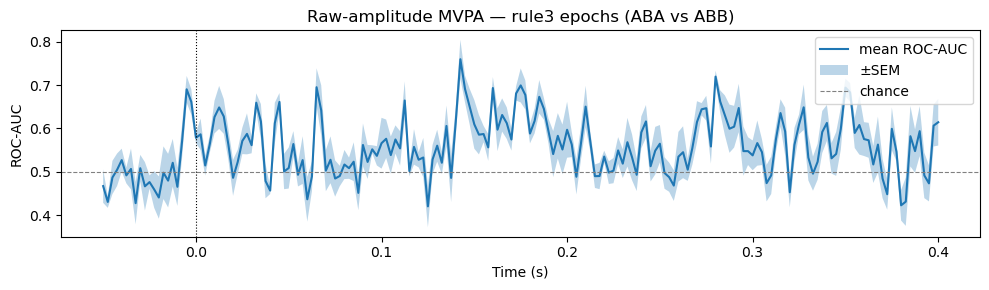

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
# t_plot = result_raw.feature_metadata['time_s']
t_plot = np.arange(len(result_raw.mean_scores)) / sfreq + feature_raw.time_window[0]
ax.plot(t_plot, result_raw.mean_scores, label='mean ROC-AUC')
ax.fill_between(
    t_plot,
    result_raw.mean_scores - result_raw.sem_scores,
    result_raw.mean_scores + result_raw.sem_scores,
    alpha=0.3, label='±SEM',
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Raw-amplitude MVPA — rule3 epochs (ABA vs ABB)')
ax.legend()
plt.tight_layout()
# plt.savefig('../figures/rule3_raw_mvpa.png', dpi=150)
plt.show()

## 4. Example 5.2 — Time-frequency (stacked) on rule3

Note: `n_cycles` is set frequency-adaptively as `freqs / 2.0` to keep wavelets
shorter than the 201-sample epoch at 400 Hz.  
Minimum required: `n_cycles/f * sfreq < 201` → for f=2 Hz, n_cycles must be < 1.
A practical choice is `n_cycles = np.maximum(freqs / 2.0, 1.0)`.

In [ ]:
import sklearn
?sklearn.linear_model.LogisticRegression

Init signature:
sklearn.linear_model.LogisticRegression(
    penalty='deprecated',
    *,
    C=1.0,
    l1_ratio=0.0,
    dual=False,
    tol=0.0001,
    fit_intercept=True,
    intercept_scaling=1,
    class_weight=None,
    random_state=None,
    solver='lbfgs',
    max_iter=100,
    verbose=0,
    warm_start=False,
    n_jobs=None,
)
Docstring:     
Logistic Regression (aka logit, MaxEnt) classifier.

This class implements regularized logistic regression using a set of available
solvers. **Note that regularization is applied by default**. It can handle both
dense and sparse input `X`. Use C-ordered arrays or CSR matrices containing 64-bit
floats for optimal performance; any other input format will be converted (and
copied).

The solvers 'lbfgs', 'newton-cg', 'newton-cholesky' and 'sag' support only L2
regularization with primal formulation, or no regularization. The 'liblinear'
solver supports both L1 and L2 regularization (but not both, i.e. elastic-net),
with a dual formulation o

In [10]:
?SVMDecoder

Init signature:
SVMDecoder(
    kernel: 'str' = 'linear',
    C: 'float' = 1.0,
    class_weight: 'Optional[str]' = 'balanced',
    n_jobs: 'int' = -1,
)
Docstring:      Linear or kernel SVM. LinearSVC is used for kernel='linear' (faster).
File:           /mnt/storage/NEU502B/brain-binding/tim/toolkit/decoders.py
Type:           ABCMeta
Subclasses:     

In [90]:
y_response = (df['response_key'] == 1).values.astype(int)
y_response.shape

(120,)

In [89]:
df

,block,sid,trial,rule_type,A_stim,B_stim,rule_sequence,test_type,X_stim,Y_stim,...,isi5,iti,t_fixation,t_rule1,t_rule2,t_rule3,t_test1,t_test2,t_test3,t_response
0,run1,1,0,ABB,triangle,circle,"triangle,circle,circle",ABA,star,rectangle,...,0.642791,2.0,21.283607,21.787256,23.025304,24.037268,26.048947,27.526128,28.676857,29.181685
1,run1,1,1,ABB,star,rectangle,"star,rectangle,rectangle",ABB,circle,rectangle,...,1.177302,2.0,35.905965,36.409975,38.204744,39.660546,41.675819,43.246760,44.935972,45.440233
2,run1,1,2,ABA,triangle,star,"triangle,star,triangle",ABA,star,rectangle,...,0.896749,2.0,51.001526,51.505513,53.090477,54.565661,56.576286,57.896963,59.304454,59.808773
3,run1,1,3,ABB,star,circle,"star,circle,circle",ABB,rectangle,star,...,1.008309,2.0,65.426719,65.930769,67.452451,69.006195,71.027570,72.673278,74.189330,74.693776
4,run1,1,4,ABA,triangle,star,"triangle,star,triangle",ABA,circle,triangle,...,1.344570,2.0,81.116279,81.619782,82.955484,84.469130,86.480262,88.036814,89.897507,90.402523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,run4,1,115,ABB,star,triangle,"star,triangle,triangle",ABB,circle,rectangle,...,0.939718,2.0,1765.302313,1765.805538,1767.917814,1769.660849,1771.682529,1773.275875,1774.727559,1775.231583
116,run4,1,116,ABB,rectangle,circle,"rectangle,circle,circle",ABB,star,circle,...,0.835053,2.0,1780.879787,1781.383062,1783.052761,1784.396140,1786.411446,1788.080769,1789.428487,1789.932847
117,run4,1,117,ABA,circle,star,"circle,star,circle",other,rectangle,circle,...,1.188723,2.0,1795.804083,1796.307439,1797.698077,1799.457055,1801.467507,1802.804232,1804.505136,1805.009049
118,run4,1,118,ABA,triangle,rectangle,"triangle,rectangle,triangle",ABA,star,triangle,...,0.699008,2.0,1810.347801,1810.851641,1812.522851,1814.003051,1816.017355,1817.529848,1818.739764,1819.244172


In [ ]:
y_star =(df['A_stim'] == "rectangle").values.astype(int)
from IPython.display import clear_output

def top_neighbors(channel_index, n_neighbors, pos): 
    """pos could be 2d or 3d"""

    # calculate distances from the given channel to all channels
    dists = np.linalg.norm(pos - pos[channel_index], axis=1)
    # get the indices of the n_neighbors closest channels (excluding itself)
    neighbor_indices = np.argsort(dists)[0:n_neighbors]
    return neighbor_indices

meg_info = mne.pick_info(epochs.info, meg_picks)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
decoder_factory_svm = lambda: SVMDecoder(C=0.01)
decoder_factory_ridge = lambda: RidgeLogisticDecoder(C=0.0001)
cv = CVSplitter(n_splits=5, stratified=True, random_state=47)
n_times = 201
freqs    = np.arange(4, 80, 4, dtype=float)          
n_cycles = 0.9 * freqs * np.pi * n_times / (5 *      
sfreq)      
feature_tf = TimeFrequencyFeature(
    freqs=freqs,
    method='morlet',
    n_cycles=n_cycles,
    mode='stacked',
    output='log_power',
    time_window=(0.0, 0.4),
    decimate=2,
    standardize=True,
)
feature_raw = RawAmplitudeFeature(time_window=(-0.05, 0.4), standardize=True)
# results_tf =np.zeros((get_stage('rule3').shape[1]//3, 6, 81))
results_raw = np.zeros((get_stage('rule3').shape[1]//3, 8, 181))
# for stage_name, X in zip(
#     ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'],
#     [X_rule1, X_rule2, X_rule3, X_trans, X_test1, X_test2],
# ):
channels_run = []
i = 0
for sensor in range(get_stage('rule3').shape[1]):
    if sensor in channels_run:
        continue

    neighbors = top_neighbors(sensor, 3, pos3d)
    neighbors_ = top_neighbors(sensor, 24, pos3d)
    channels_run.extend(list(neighbors_))
    X_rule1 = get_stage('rule1')[:, neighbors]
    X_rule2 = get_stage('rule2')[:, neighbors]
    X_rule3 = get_stage('rule3')[:, neighbors]
    X_trans = get_stage('transition')[:, neighbors]
    X_test1 = get_stage('test1')[:, neighbors]
    X_test2 = get_stage('test2')[:, neighbors]

    for stage_name, X in zip(
        ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2', 'test3', 'response'],
        [X_rule1, X_rule2, X_rule3, X_trans, X_test1, X_test2, get_stage('test3')[:, neighbors], get_stage('response')[:, neighbors]]
    ):
        result_raw = cross_validate(
            feature_raw, decoder_factory_ridge,
            X, y_star, sfreq=sfreq, times=times,
            cv=cv, metric='roc_auc', return_train_scores=True
        )
        # result_tf = cross_validate(
        #     feature_tf, decoder_factory_ridge,
        #     X, y_rule, sfreq=sfreq, times=times,
        #     cv=cv, metric='roc_auc',return_train_scores=True
        # )
        print(f'{stage_name} result: {result_raw}, training average = {result_raw.train_scores.mean():.3f}')
        results_raw[i, ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2', 'test3', 'response'].index(stage_name), :] = result_raw.mean_scores
        # results_tf[i, ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'].index(stage_name), :] = result_tf.mean_scores
        # print(f'{stage_name} result: {result_tf}, training average = {result_tf.train_scores.mean():.3f}')
    stage_names = ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2', 'test3', 'response']

    i += 1
    results_raw_avg = results_raw[:i].mean(axis=0)  # shape: (6, n_times)
    results_raw_std = results_raw[:i].std(axis=0)   # shape: (6, n_times)

    t_plot_base = np.arange(results_raw.shape[-1]) / sfreq + feature_raw.time_window[0]

    clear_output(wait=True)
    plt.close('all')
    fig, ax = plt.subplots(figsize=(11, 4))

    for k, stage in enumerate(stage_names):
        t_plot = t_plot_base + 0.4 * k
        ax.plot(t_plot, results_raw_avg[k], label=stage)
        ax.fill_between(
            t_plot,
            results_raw_avg[k] - results_raw_std[k],
            results_raw_avg[k] + results_raw_std[k],
            alpha=0.2,
        )

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
    ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('Average decodability traces across task stages')
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()

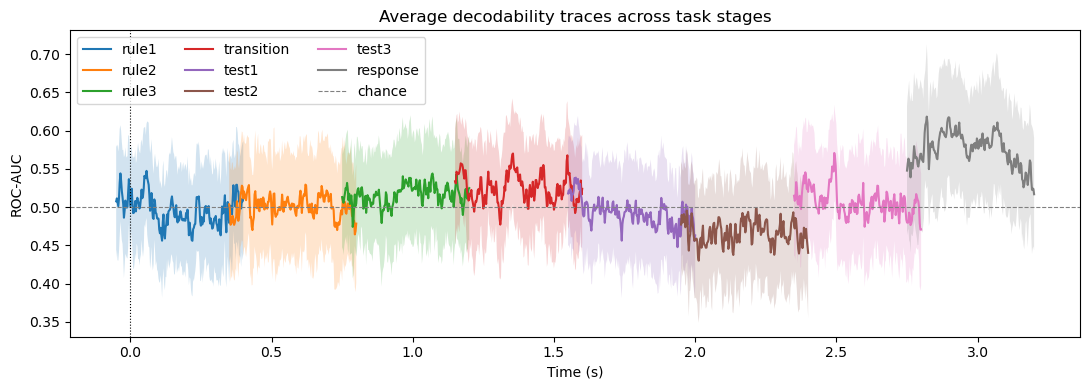

In [ ]:
from IPython.display import clear_output

def top_neighbors(channel_index, n_neighbors, pos): 
    """pos could be 2d or 3d"""

    # calculate distances from the given channel to all channels
    dists = np.linalg.norm(pos - pos[channel_index], axis=1)
    # get the indices of the n_neighbors closest channels (excluding itself)
    neighbor_indices = np.argsort(dists)[0:n_neighbors]
    return neighbor_indices

meg_info = mne.pick_info(epochs.info, meg_picks)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
decoder_factory_svm = lambda: SVMDecoder(C=0.01)
decoder_factory_ridge = lambda: RidgeLogisticDecoder(C=0.0001)
cv = CVSplitter(n_splits=5, stratified=True, random_state=47)
n_times = 201
freqs    = np.arange(4, 80, 4, dtype=float)          
n_cycles = 0.9 * freqs * np.pi * n_times / (5 *      
sfreq)      
feature_tf = TimeFrequencyFeature(
    freqs=freqs,
    method='morlet',
    n_cycles=n_cycles,
    mode='stacked',
    output='log_power',
    time_window=(0.0, 0.4),
    decimate=2,
    standardize=True,
)
feature_raw = RawAmplitudeFeature(time_window=(-0.05, 0.4), standardize=True)
# results_tf =np.zeros((get_stage('rule3').shape[1]//3, 6, 81))
results_raw = np.zeros((get_stage('rule3').shape[1]//3, 8, 181))
# for stage_name, X in zip(
#     ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'],
#     [X_rule1, X_rule2, X_rule3, X_trans, X_test1, X_test2],
# ):
channels_run = []
i = 0
for sensor in range(get_stage('rule3').shape[1]):
    if sensor in channels_run:
        continue

    neighbors = top_neighbors(sensor, 3, pos3d)
    neighbors_ = top_neighbors(sensor, 3, pos3d)
    channels_run.extend(list(neighbors_))
    X_rule1 = get_stage('rule1')[:, neighbors]
    X_rule2 = get_stage('rule2')[:, neighbors]
    X_rule3 = get_stage('rule3')[:, neighbors]
    X_trans = get_stage('transition')[:, neighbors]
    X_test1 = get_stage('test1')[:, neighbors]
    X_test2 = get_stage('test2')[:, neighbors]

    for stage_name, X in zip(
        ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2', 'test3', 'response'],
        [X_rule1, X_rule2, X_rule3, X_trans, X_test1, X_test2, get_stage('test3')[:, neighbors], get_stage('response')[:, neighbors]]
    ):
        result_raw = cross_validate(
            feature_raw, decoder_factory_ridge,
            X, y_response, sfreq=sfreq, times=times,
            cv=cv, metric='roc_auc', return_train_scores=True
        )
        # result_tf = cross_validate(
        #     feature_tf, decoder_factory_ridge,
        #     X, y_rule, sfreq=sfreq, times=times,
        #     cv=cv, metric='roc_auc',return_train_scores=True
        # )
        print(f'{stage_name} result: {result_raw}, training average = {result_raw.train_scores.mean():.3f}')
        results_raw[i, ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2', 'test3', 'response'].index(stage_name), :] = result_raw.mean_scores
        # results_tf[i, ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'].index(stage_name), :] = result_tf.mean_scores
        # print(f'{stage_name} result: {result_tf}, training average = {result_tf.train_scores.mean():.3f}')
    stage_names = ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2', 'test3', 'response']

    i += 1
    results_raw_avg = results_raw[:i].mean(axis=0)  # shape: (6, n_times)
    results_raw_std = results_raw[:i].std(axis=0)   # shape: (6, n_times)

    t_plot_base = np.arange(results_raw.shape[-1]) / sfreq + feature_raw.time_window[0]

    clear_output(wait=True)
    plt.close('all')
    fig, ax = plt.subplots(figsize=(11, 4))

    for k, stage in enumerate(stage_names):
        t_plot = t_plot_base + 0.4 * k
        ax.plot(t_plot, results_raw_avg[k], label=stage)
        ax.fill_between(
            t_plot,
            results_raw_avg[k] - results_raw_std[k],
            results_raw_avg[k] + results_raw_std[k],
            alpha=0.2,
        )

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
    ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('Average decodability traces across task stages')
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()


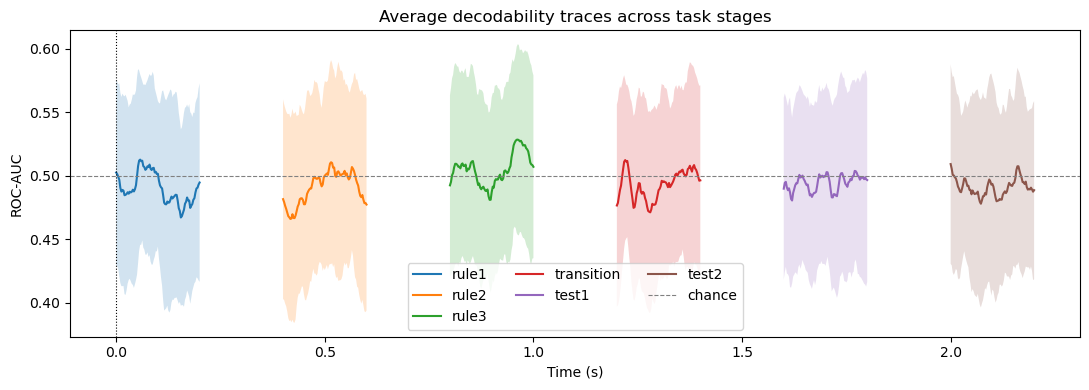

In [75]:
from IPython.display import clear_output

def top_neighbors(channel_index, n_neighbors, pos): 
    """pos could be 2d or 3d"""

    # calculate distances from the given channel to all channels
    dists = np.linalg.norm(pos - pos[channel_index], axis=1)
    # get the indices of the n_neighbors closest channels (excluding itself)
    neighbor_indices = np.argsort(dists)[0:n_neighbors]
    return neighbor_indices

meg_info = mne.pick_info(epochs.info, meg_picks)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
decoder_factory_svm = lambda: SVMDecoder(C=0.01)
decoder_factory_ridge = lambda: RidgeLogisticDecoder(C=0.0001)
cv = CVSplitter(n_splits=5, stratified=True, random_state=47)
n_times = 201
freqs    = np.arange(4, 80, 4, dtype=float)          
n_cycles = 0.9 * freqs * np.pi * n_times / (5 *      
sfreq)      
feature_tf = TimeFrequencyFeature(
    freqs=freqs,
    method='morlet',
    n_cycles=n_cycles,
    mode='stacked',
    output='log_power',
    time_window=(0.0, 0.4),
    decimate=2,
    standardize=True,
)
# feature_raw = RawAmplitudeFeature(time_window=(-0.05, 0.4), standardize=True)
results_tf =np.zeros((get_stage('rule3').shape[1]//3, 6, 81))
# results_raw = np.zeros((get_stage('rule3').shape[1]//3, 6, 181))
# for stage_name, X in zip(
#     ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'],
#     [X_rule1, X_rule2, X_rule3, X_trans, X_test1, X_test2],
# ):
channels_run = []
i = 0
for sensor in range(get_stage('rule3').shape[1]):
    if sensor in channels_run:
        continue

    neighbors = top_neighbors(sensor, 3, pos3d)
    neighbors_ = top_neighbors(sensor, 3, pos3d)
    channels_run.extend(list(neighbors_))
    X_rule1 = get_stage('rule1')[:, neighbors]
    X_rule2 = get_stage('rule2')[:, neighbors]
    X_rule3 = get_stage('rule3')[:, neighbors]
    X_trans = get_stage('transition')[:, neighbors]
    X_test1 = get_stage('test1')[:, neighbors]
    X_test2 = get_stage('test2')[:, neighbors]

    for stage_name, X in zip(
        ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'],
        [X_rule1, X_rule2, X_rule3, X_trans, X_test1, X_test2],
    ):
        # result_raw = cross_validate(
        #     feature_raw, decoder_factory_ridge,
        #     X, y_rule, sfreq=sfreq, times=times,
        #     cv=cv, metric='roc_auc', return_train_scores=True
        # )
        result_tf = cross_validate(
            feature_tf, decoder_factory_ridge,
            X, y_rule, sfreq=sfreq, times=times,
            cv=cv, metric='roc_auc',return_train_scores=True
        )
        # print(f'{stage_name} result: {result_raw}, training average = {result_raw.train_scores.mean():.3f}')
        # results_raw[i, ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'].index(stage_name), :] = result_raw.mean_scores
        results_tf[i, ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2'].index(stage_name), :] = result_tf.mean_scores
        print(f'{stage_name} result: {result_tf}, training average = {result_tf.train_scores.mean():.3f}')
    stage_names = ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2']

    i += 1
    results_raw_avg = results_tf[:i].mean(axis=0)  # shape: (6, n_times)
    results_raw_std = results_tf[:i].std(axis=0)   # shape: (6, n_times)

    t_plot_base = np.arange(results_tf.shape[-1]) / sfreq + feature_tf.time_window[0]

    clear_output(wait=True)
    plt.close('all')
    fig, ax = plt.subplots(figsize=(11, 4))

    for k, stage in enumerate(stage_names):
        t_plot = t_plot_base + 0.4 * k
        ax.plot(t_plot, results_raw_avg[k], label=stage)
        ax.fill_between(
            t_plot,
            results_raw_avg[k] - results_raw_std[k],
            results_raw_avg[k] + results_raw_std[k],
            alpha=0.2,
        )

    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
    ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('Average decodability traces across task stages')
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()


In [ ]:
np.save('../rule_decoding_raw.npy', results_raw)

In [100]:
results_raw_response = np.load("../rule_decoding_raw_star.npy")

In [104]:
results_raw_response[:, -1].mean()

0.5753845337203849

In [22]:
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results_tf[:, :, -3].mean(axis=1)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

topo_scores = np.array([scores[groups == g].mean() for g in range(groups.max() + 1)])
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])



In [27]:
top_neighbors(0, 5, pos3d)

array([ 1,  2, 24, 25, 26])

In [30]:
pos3d[top_neighbors(0, 5, pos3d)]


AxisError: axis 1 is out of bounds for array of dimension 1

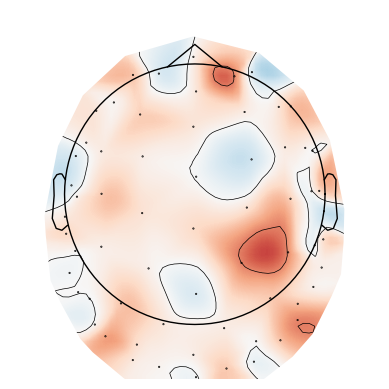

In [115]:
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results_raw_response[:, 7, 0:2].mean(axis=1)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

# topo_scores = np.array([scores[groups == g].mean() for g in range(groups.max() + 1)])
topo_scores = scores
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])

# Center and scale 2D positions for plotting
# topo_pos = topo_pos - topo_pos.mean(axis=0, keepdims=True)
# topo_pos = topo_pos / np.abs(topo_pos).max()

fig, ax = plt.subplots()
mne.viz.plot_topomap(
    topo_scores,
    topo_pos,
    axes=ax,
    cmap='RdBu_r',
    contours=1,
    sensors=True,
    vlim = (0, 1), 
    extrapolate='local', 
)


ax.set_title('Rule3 mean ROC-AUC topomap')
plt.show()

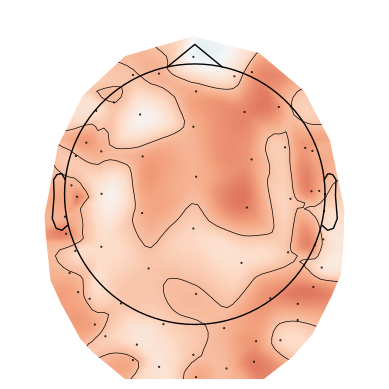

In [83]:
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results_raw[:, 3, :].mean(axis=1)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

# topo_scores = np.array([scores[groups == g].mean() for g in range(groups.max() + 1)])
topo_scores = scores
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])

# Center and scale 2D positions for plotting
# topo_pos = topo_pos - topo_pos.mean(axis=0, keepdims=True)
# topo_pos = topo_pos / np.abs(topo_pos).max()

fig, ax = plt.subplots()
mne.viz.plot_topomap(
    topo_scores,
    topo_pos,
    axes=ax,
    cmap='RdBu_r',
    contours=1,
    sensors=True,
    vlim = (0.3, 0.7), 
    extrapolate='local', 
)


ax.set_title('Rule3 mean ROC-AUC topomap')
plt.show()

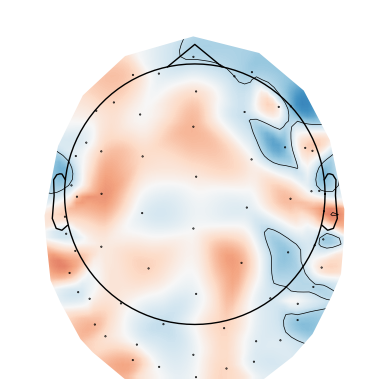

In [ ]:
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results_tf[:, 0, -1:].mean(axis=1)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

topo_scores = np.array([scores[groups == g].mean() for g in range(groups.max() + 1)])
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])

fig, ax = plt.subplots()
mne.viz.plot_topomap(
    topo_scores,
    topo_pos,
    axes=ax,
    cmap='RdBu_r',
    contours=1,
    sensors=True,
    vlim = (0.3, 0.7),
    extrapolate='local', 
)
ax.set_title('Rule3 mean ROC-AUC topomap')
plt.show()

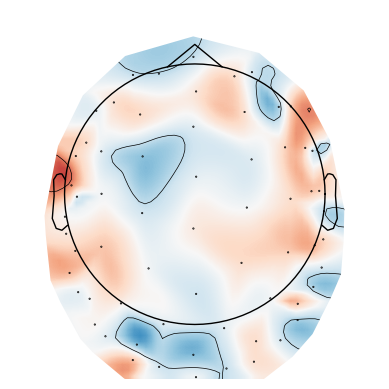

In [ ]:
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results_tf[:, 1, -5:].mean(axis=1)

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

topo_scores = np.array([scores[groups == g].mean() for g in range(groups.max() + 1)])
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])

fig, ax = plt.subplots()
mne.viz.plot_topomap(
    topo_scores,
    topo_pos,
    axes=ax,
    cmap='RdBu_r',
    contours=1,
    sensors=True,
    vlim = (0.3, 0.7),
    extrapolate='local', 
)
ax.set_title('Rule3 mean ROC-AUC topomap')
plt.show()

In [57]:
from toolkit import viz

In [ ]:
meg_picks = mne.pick_types(epochs.info, meg=True, exclude=[])
meg_info = mne.pick_info(epochs.info, meg_picks)

scores = results_tf[:, 1, :]

# Group channels that have the same sensor location (e.g. X/Y/Z components)
pos3d = np.array([ch['loc'][:3] for ch in meg_info['chs']])
pos_key = np.round(pos3d, 6)
_, groups = np.unique(pos_key, axis=0, return_inverse=True)

topo_scores = np.array([scores[groups == g].mean(axis=0) for g in range(groups.max() + 1)])
topo_pos = np.array([pos3d[groups == g, :2].mean(axis=0) for g in range(groups.max() + 1)])


<Axes: >

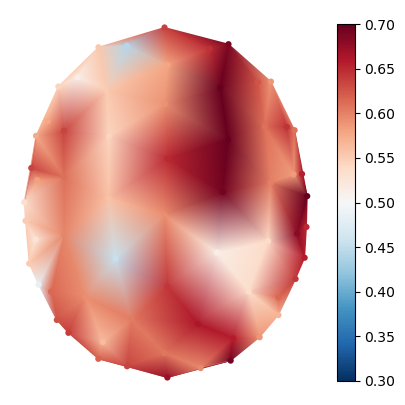

In [65]:
# pos, names = viz.get_sensor_positions(epochs.info, "Z")
viz.plot_sensor_map(results_raw[:, 2, -1], topo_pos, vmin = 0.3, vmax = 0.7, cmap = 'RdBu_r', alpha = 1)


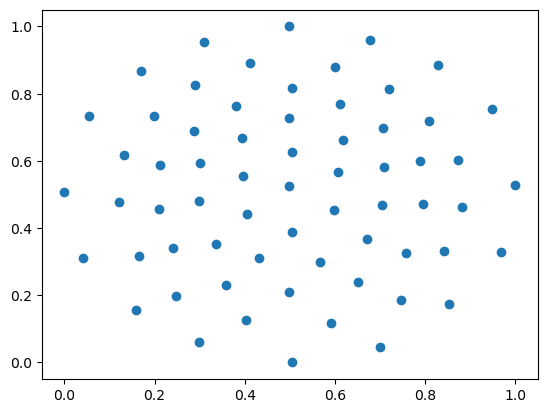

In [ ]:
plt.scatter(pos[:, 0], pos[:, 1])

<Axes3D: xlabel='x', ylabel='y', zlabel='time (s)'>

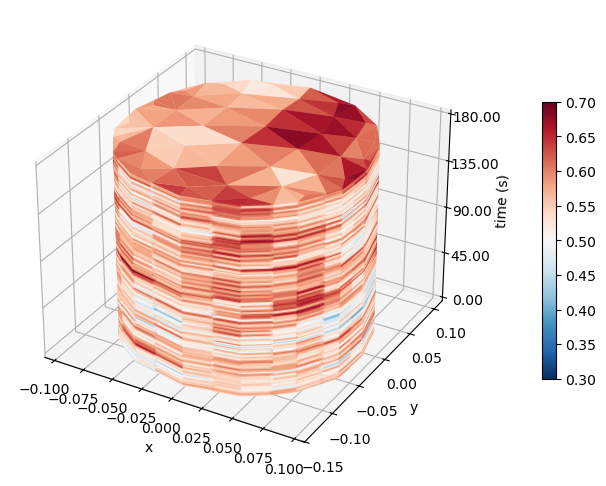

In [66]:
scores = results_raw[:, 2, :]
viz.plot_sensor_map_3d(scores, topo_pos, vmin = 0.3, vmax = 0.7, cmap = 'RdBu_r', alpha = 1,)

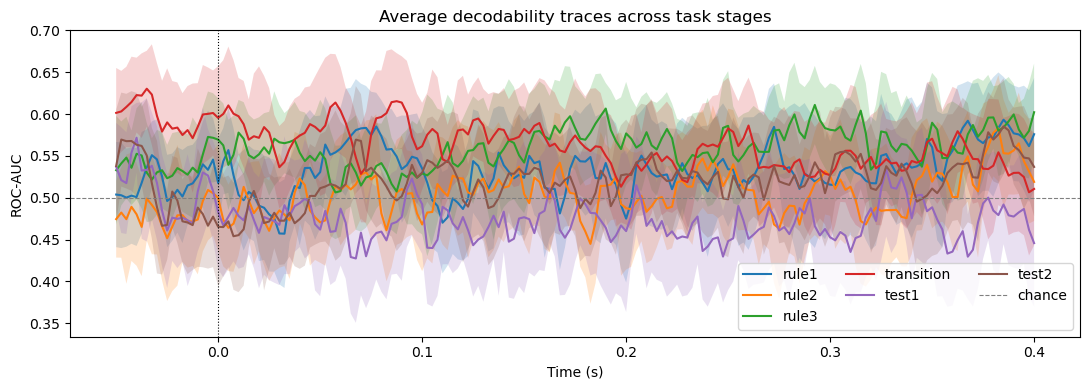

In [69]:
stage_names = ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2']

results_raw_avg = results_raw.mean(axis=0)  # shape: (6, n_times)
results_raw_std = results_raw.std(axis=0)   # shape: (6, n_times)

t_plot = np.arange(results_raw.shape[-1]) / sfreq + feature_raw.time_window[0]

fig, ax = plt.subplots(figsize=(11, 4))

for k, stage in enumerate(stage_names):
    ax.plot(t_plot, results_raw_avg[k], label=stage)
    ax.fill_between(
        t_plot,
        results_raw_avg[k] - results_raw_std[k],
        results_raw_avg[k] + results_raw_std[k],
        alpha=0.2,
    )

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Average decodability traces across task stages')
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

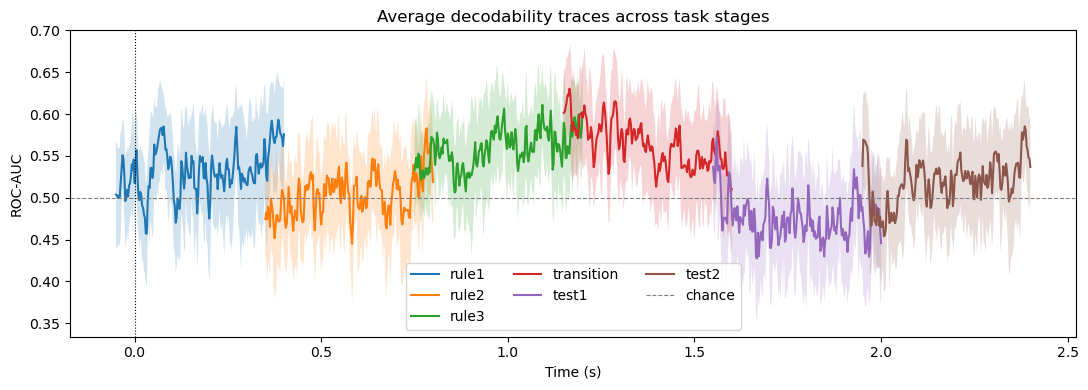

In [70]:
stage_names = ['rule1', 'rule2', 'rule3', 'transition', 'test1', 'test2']

results_raw_avg = results_raw.mean(axis=0)  # shape: (6, n_times)
results_raw_std = results_raw.std(axis=0)   # shape: (6, n_times)

# t_plot = np.arange(results_raw.shape[-1]) / sfreq + feature_raw.time_window[0]

fig, ax = plt.subplots(figsize=(11, 4))

for k, stage in enumerate(stage_names):
    ax.plot(t_plot, results_raw_avg[k], label=stage)
    ax.fill_between(
        t_plot,
        results_raw_avg[k] - results_raw_std[k],
        results_raw_avg[k] + results_raw_std[k],
        alpha=0.2,
    )
    t_plot+= 0.4  # shift time axis for better visualization

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Average decodability traces across task stages')
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

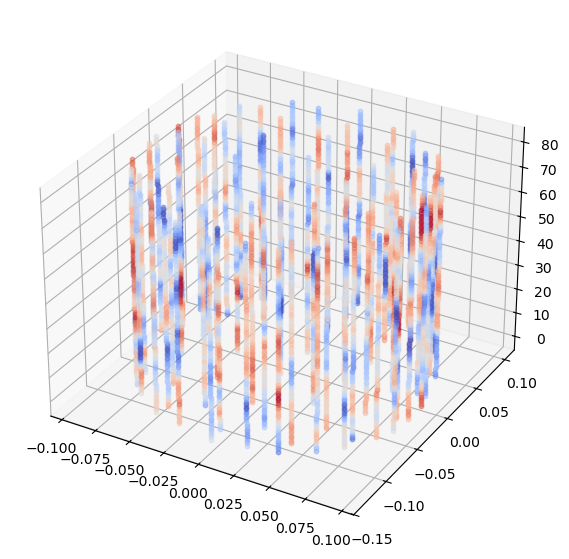

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for sensor, (pos, score) in enumerate(zip(topo_pos, topo_scores[:, :])):
    for t in range(len(score)):
        scoret = (max(min(score[t], 0.6), 0.4) - 0.5) * 5 + 0.5
        ax.scatter(pos[0], pos[1], t, color=plt.cm.coolwarm(scoret), s=10, alpha=0.5)


In [ ]:
pos, names = viz.get_sensor_positions(epochs.info, "Z")
viz.plot_sensor_map(topo_scores, pos, vmin = 0.3, vmax = 0.7, cmap = 'RdBu_r', alpha = 1)

In [ ]:
viz.plot_sensor_map_3d

In [ ]:
pos, name = viz.get_sensor_positions(epochs.info, None)

In [ ]:
pos.shape

(192, 2)

In [ ]:
?mne.viz.plot_topomap

Signature:
mne.viz.plot_topomap(
    data,
    pos,
    *,
    ch_type='eeg',
    sensors=True,
    names=None,
    mask=None,
    mask_params=None,
    contours=6,
    outlines='head',
    sphere=None,
    image_interp='cubic',
    extrapolate='auto',
    border='mean',
    res=64,
    size=1,
    cmap=None,
    vlim=(None, None),
    cnorm=None,
    axes=None,
    show=True,
    onselect=None,
)
Docstring:
Plot a topographic map as image.

Parameters
----------
data : array, shape (n_chan,)
    The data values to plot.
pos : array, shape (n_channels, 2) | instance of Info
    Location information for the channels. If an array, should provide the x
    and y coordinates for plotting the channels in 2D.
    If an :class:`~mne.Info` object it must contain only one channel type
    and exactly ``len(data)`` channels; the x/y coordinates will
    be inferred from the montage in the :class:`~mne.Info` object.
ch_type : 'mag' | 'grad' | 'planar1' | 'planar2' | 'eeg' | None
    The channel t

In [ ]:
mne.viz.get_sensor_positions

AttributeError: No mne.viz attribute get_sensor_positions

In [ ]:
?mne.viz.plot_topomap

Signature:
mne.viz.plot_topomap(
    data,
    pos,
    *,
    ch_type='eeg',
    sensors=True,
    names=None,
    mask=None,
    mask_params=None,
    contours=6,
    outlines='head',
    sphere=None,
    image_interp='cubic',
    extrapolate='auto',
    border='mean',
    res=64,
    size=1,
    cmap=None,
    vlim=(None, None),
    cnorm=None,
    axes=None,
    show=True,
    onselect=None,
)
Docstring:
Plot a topographic map as image.

Parameters
----------
data : array, shape (n_chan,)
    The data values to plot.
pos : array, shape (n_channels, 2) | instance of Info
    Location information for the channels. If an array, should provide the x
    and y coordinates for plotting the channels in 2D.
    If an :class:`~mne.Info` object it must contain only one channel type
    and exactly ``len(data)`` channels; the x/y coordinates will
    be inferred from the montage in the :class:`~mne.Info` object.
ch_type : 'mag' | 'grad' | 'planar1' | 'planar2' | 'eeg' | None
    The channel t

In [ ]:
epochs.info

<Info | 14 non-empty values
 bads: []
 ch_names: BNC 1 Z, BNC 2 Z, BNC 3 Z, BNC 4 Z, BNC 5 Z, BNC 6 Z, BNC 7 Z, ...
 chs: 8 Stimulus, 192 Magnetometers, 6 Reference Magnetometers
 custom_ref_applied: False
 device_info: 2 items (dict)
 dig: 0 items
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 line_freq: 60.0
 lowpass: 100.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 206
 projs: HFC: l=1 m=-1: on, HFC: l=1 m=0: on, HFC: l=1 m=1: on, HFC: l=2 ...
 sfreq: 400.0 Hz
 subject_info: <subject_info | his_id: sub-001, sex: 0, hand: 0>
>

In [ ]:
get_stage('rule3').shape[1]

192

In [ ]:
result_tf.mean_scores.shape

(81,)

In [ ]:
results_tf[-1].train_scores

array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.  

In [ ]:
feature_tf.freqs

array([ 4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24., 26., 28.,
       30., 32., 34., 36., 38.])

In [ ]:
feature_fold = feature_tf.clone()
feature_fold.fit(X_rule3[0:5], sfreq, times)
f_train = feature_fold.transform(X_rule3[0:5])   # (n_models, n_tr, fd)
f_test  = feature_fold.transform(X_rule3[5:10])    # (n_models, n_te, fd)

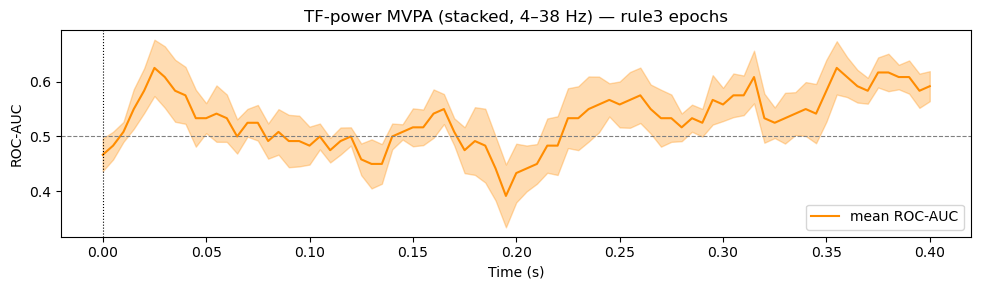

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
# t_plot_tf = result_tf.feature_metadata['time_s']
t_plot_tf = np.arange(len(result_tf.mean_scores)) * feature_tf.decimate / sfreq + feature_tf.time_window[0]
ax.plot(t_plot_tf, result_tf.mean_scores, color='darkorange', label='mean ROC-AUC')
ax.fill_between(
    t_plot_tf,
    result_tf.mean_scores - result_tf.sem_scores,
    result_tf.mean_scores + result_tf.sem_scores,
    alpha=0.3, color='darkorange',
)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ROC-AUC')
ax.set_title('TF-power MVPA (stacked, 4–38 Hz) — rule3 epochs')
ax.legend()
plt.tight_layout()
# plt.savefig('../figures/rule3_tf_mvpa.png', dpi=150)
plt.show()

## 5. Example 5.3 — Riemannian covariance on transition epochs

In [ ]:
X_transition = get_stage('transition')
print(f'transition shape: {X_transition.shape}')

feature_riem = RiemannianCovarianceFeature(
    window_size=None,      # whole epoch
    estimator='oas',
    tangent_space=True,
    reference='riemann',
)
decoder_factory_svm = lambda: SVMDecoder(C=1.0, class_weight='balanced')

result_riem = cross_validate(
    feature_riem, decoder_factory_svm,
    X_transition, y_rule, sfreq=sfreq, times=times,
    cv=cv, metric='roc_auc',
)
print(result_riem)
print(f'\nMean ROC-AUC (transition, Riemannian): {result_riem.mean_scores[0]:.4f} ± {result_riem.sem_scores[0]:.4f}')

transition shape: (120, 192, 201)


/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/pyriemann/utils/base.py:91: RuntimeWarning: invalid value encountered in sqrt
  eigvals = operator(eigvals)
/home/timmy/miniconda3/envs/test/lib/python3.12/site-packages/pyriemann/utils/base.py:144: RuntimeWarning: invalid value encountered in sqrt
  def isqrt(x): return 1. / np.sqrt(x)


ValueError: Matrices must be positive definite. You should add regularization to avoid this error.

## 6. Compare all three decoders on rule3 (raw amplitude)

In [ ]:
from toolkit import DeepMLPDecoder

results = {}
factories = {
    'Ridge': lambda: RidgeLogisticDecoder(C=1.0),
    'SVM':   lambda: SVMDecoder(C=1.0),
    'MLP':   lambda: DeepMLPDecoder(hidden_dims=[128, 64], max_epochs=200,
                                     early_stopping_patience=20, verbose=False),
}

for name, factory in factories.items():
    print(f'Running {name}...')
    results[name] = cross_validate(
        RawAmplitudeFeature(time_window=(-0.05, 0.4), standardize=True),
        factory, X_rule3, y_rule, sfreq=sfreq, times=times,
        cv=cv, metric='roc_auc',
    )
    print(f'  {results[name]}')

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = {'Ridge': '#1f77b4', 'SVM': '#ff7f0e', 'MLP': '#2ca02c'}

for name, res in results.items():
    t_plot = res.feature_metadata['time_s']
    ax.plot(t_plot, res.mean_scores, color=colors[name], label=name)
    ax.fill_between(
        t_plot,
        res.mean_scores - res.sem_scores,
        res.mean_scores + res.sem_scores,
        alpha=0.15, color=colors[name],
    )

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='chance')
ax.axvline(0.0, color='k', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Decoder comparison — rule3 raw amplitude (ABA vs ABB)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/rule3_decoder_comparison.png', dpi=150)
plt.show()